Generated raw data with shape: (240, 5)

--- Part 1: Data Inspection and Pre-processing ---
Visualizing raw data to identify bias...


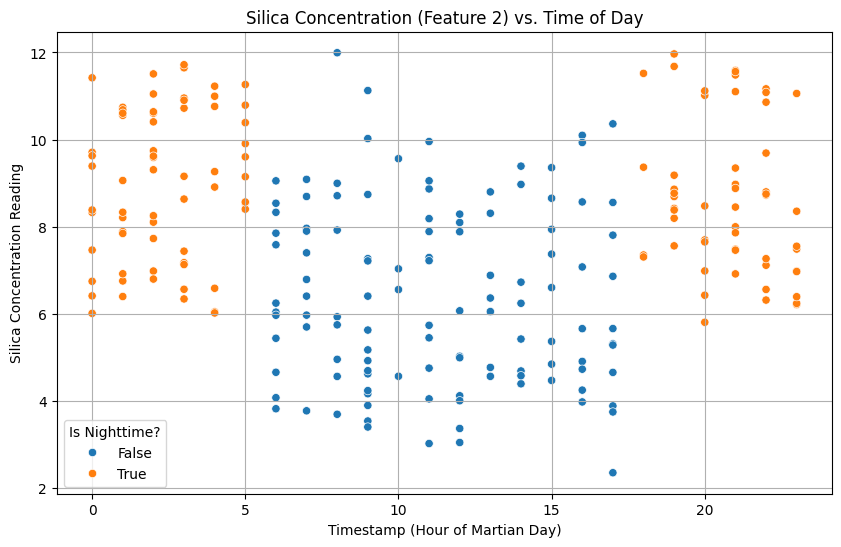

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal

# --- Data Generation ---
# This function is provided for you. Do not modify it.
def generate_mars_data():
    """
    Generates a synthetic Mars rover dataset.

    - 3 true Gaussian clusters (rock types).
    - Feature at index 2 (silica) is biased upwards by +2.5 for
      readings taken at night (18:00-06:00).
    - ~5% of the data are random outliers from ChemCam "misfires".

    Returns:
        tuple: (data, timestamps)
               - data (np.ndarray): A (250, 5) numpy array.
               - timestamps (np.ndarray): A (250,) array of hours (0-23).
    """
    np.random.seed(42)

    ##Define the true clusters
    means = [
        [5.1, 3.5, 4.4, 1.2, 1.1], # Igneous
        [8.5, 3.0, 8.5, 3.8, 2.3], # Sedimentary
        [6.8, 2.7, 6.1, 2.2, 1.5]  # Altered by Water
    ]
    covs = [
        np.diag([0.3, 0.4, 0.5, 0.3, 0.2]),
        np.diag([0.5, 0.3, 0.6, 0.4, 0.4]),
        np.diag([0.4, 0.3, 0.5, 0.3, 0.3])
    ]

    n_samples_per_cluster = 75

    # Generate true data
    true_data = np.vstack([np.random.multivariate_normal(m, c, n_samples_per_cluster) for m, c in zip(means, covs)])

    # Add outliers
    n_outliers = 15
    outliers = np.random.uniform(low=0, high=12, size=(n_outliers, 5))

    # Combine true data and outliers
    data = np.vstack([true_data, outliers])

    # Generate timestamps and apply conditional bias
    n_total = data.shape[0]
    timestamps = np.random.randint(0, 24, n_total)

    # Apply bias to silica reading (feature 2) for nighttime readings
    night_mask = (timestamps >= 18) | (timestamps < 6)
    data[night_mask, 2] += 2.5 # Additive bias

    # Shuffle everything
    shuffle_idx = np.random.permutation(n_total)
    data = data[shuffle_idx]
    timestamps = timestamps[shuffle_idx]

    return data, timestamps


raw_data, timestamps = generate_mars_data()
print(f"Generated raw data with shape: {raw_data.shape}")

print("\n--- Part 1: Data Inspection and Pre-processing ---")

# Part 1 - Task 1: Generate and Inspect the Data (provided for you)
print("Visualizing raw data to identify bias...")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=timestamps, y=raw_data[:, 2], hue=(timestamps >= 18) | (timestamps < 6))
plt.title("Silica Concentration (Feature 2) vs. Time of Day")
plt.xlabel("Timestamp (Hour of Martian Day)")
plt.ylabel("Silica Concentration Reading")
plt.legend(title="Is Nighttime?")
plt.grid(True)
plt.show()

[[ 9.74121341  3.35348697 10.09624848  3.64254125  2.91447542]
 [ 0.30770479  4.09497393  4.56234743  4.78587337  6.96206843]
 [ 8.5098495   2.92093055 11.0458704   3.78474196  2.4252798 ]
 ...
 [ 5.29807621  3.4544568   7.85900652  1.74965761  0.81149368]
 [ 6.87229593  3.90098592  8.28694587  2.84170903  3.16448719]
 [ 6.96889742  3.28358764  7.54955019  2.2450688   1.98727085]]
Visualizing raw data to identify bias...


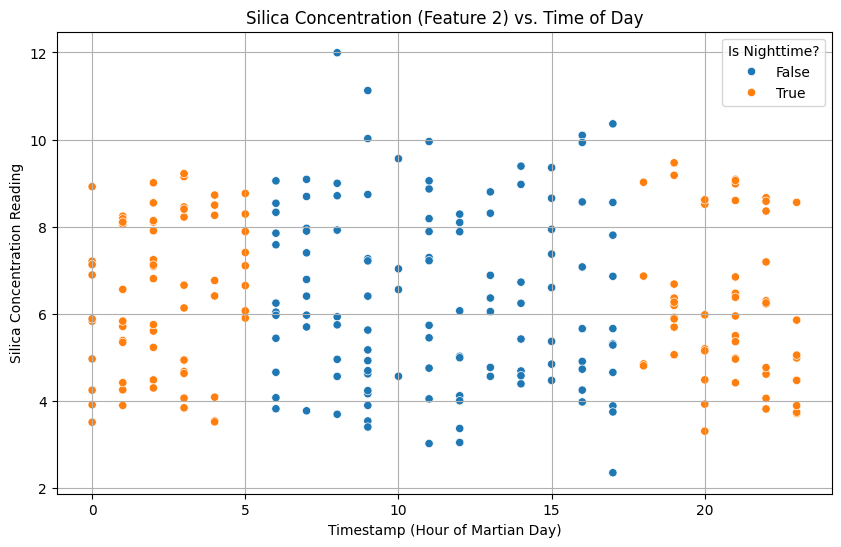

[[ 9.74121341  3.35348697 10.09624848  3.64254125  2.91447542]
 [ 0.30770479  4.09497393  4.56234743  4.78587337  6.96206843]
 [ 8.5098495   2.92093055  8.5458704   3.78474196  2.4252798 ]
 ...
 [ 5.29807621  3.4544568   5.35900652  1.74965761  0.81149368]
 [ 6.87229593  3.90098592  8.28694587  2.84170903  3.16448719]
 [ 6.96889742  3.28358764  5.04955019  2.2450688   1.98727085]]


In [3]:
# Part 1 - Task 2: Correct for Systematic Bias (5 points)
corrected_data, timestamps = generate_mars_data()
night_mask = (timestamps >= 18) | (timestamps < 6)
print(raw_data)
corrected_data[night_mask, 2] -= 2.5
print("Visualizing raw data to identify bias...")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=timestamps, y=corrected_data[:, 2], hue=(timestamps >= 18) | (timestamps < 6))
plt.title("Silica Concentration (Feature 2) vs. Time of Day")
plt.xlabel("Timestamp (Hour of Martian Day)")
plt.ylabel("Silica Concentration Reading")
plt.legend(title="Is Nighttime?")
plt.grid(True)
plt.show()
print(corrected_data)

In [4]:


# --- Part 2: Robust Mixture Model from Scratch (25 Points) ---
print("\n--- Part 2: Robust Mixture Model from Scratch ---")

class RobustMixtureModel:
    def __init__(self, n_gaussians=3, n_iter=100):
        self.n_gaussians = n_gaussians
        self.n_components = n_gaussians + 1 # +1 for the uniform outlier model
        self.n_iter = n_iter


    def _e_step(self, X):
        # Calculate likelihoods for each component
        likelihoods = np.zeros((X.shape[0], self.n_components))

        # Gaussian components
        for k in range(self.n_gaussians):
            dist = multivariate_normal(self.means[k], self.covs[k], allow_singular=True)
            likelihoods[:, k] = dist.pdf(X)

        # Uniform component
        likelihoods[:, self.n_gaussians] = self.uniform_density

        # Calculate responsibilities
        numerator = likelihoods * self.weights
        denominator = numerator.sum(axis=1)[:, np.newaxis]
        # Add a small epsilon to denominator to avoid division by zero
        responsibilities = numerator / (denominator + 1e-9)
        return responsibilities

    def _m_step(self, X, responsibilities):
          # Part 2 - Task 2: implementing the update step (15 points)
          # __code below__
        self.means = []
        for column in np.transpose(responsibilities):
            row_mean = []
            for data_column in np.transpose(X):
                mean_dot_respos = np.dot(column, data_column)
                row_mean.append(mean_dot_respos/ np.sum(column))
            self.means.append(row_mean)

        self.covs = []
        for index in range(len(np.transpose(responsibilities))):
            column = np.transpose(responsibilities)[index]
            present_mean = self.means[index]
            row_covs = np.zeros((5,5))
            for i in range(len(present_mean)):
                squared_diff = (np.transpose(X)[i] - present_mean[i]) ** 2
                variance = np.dot(column, squared_diff) / np.sum(column)
                row_covs[i, i] = variance
                if i != len(present_mean) -1:
                    for n in range(i + 1, len(present_mean)):
                        difference1 = np.transpose(X)[i] - present_mean[i]
                        difference2 = np.transpose(X)[n] -  present_mean[n]
                        covariance = np.dot(difference1 * difference2, column) / np.sum(column)
                        row_covs[i, n] = covariance
                        row_covs[n, i] = covariance
            self.covs.append(row_covs)

        self.weights = []
        total_weights = 0
        for column in np.transpose(responsibilities):
            total_weights += np.sum(column)
        for column in np.transpose(responsibilities):
            weight = np.sum(column) / total_weights
            self.weights.append(weight)



    def fit(self, X):
        n_samples, n_features = X.shape

        # Part 2 - Task 3: perform the main training loop (10 points)

        # Initialize parameters
        # Gaussian params
        np.random.seed(410)
        self.means = [
             [np.random.choice(np.transpose(X)[0]),
                      np.random.choice(np.transpose(X)[1]),
                    np.random.choice(np.transpose(X)[2]),np.random.choice(np.transpose(X)[3]),
                    np.random.choice(np.transpose(X)[4])],
            [np.random.choice(np.transpose(X)[0]),
                      np.random.choice(np.transpose(X)[1]),
                    np.random.choice(np.transpose(X)[2]),np.random.choice(np.transpose(X)[3]),
                np.random.choice(np.transpose(X)[4])],
           [np.random.choice(np.transpose(X)[0]),
                      np.random.choice(np.transpose(X)[1]),
                    np.random.choice(np.transpose(X)[2]),np.random.choice(np.transpose(X)[3]),
                    np.random.choice(np.transpose(X)[4])],
        ]
        self.covs =  [np.identity(5), np.identity(5), np.identity(5)]

        # All weights (Gaussians + Uniform)
        self.weights = np.ones(self.n_components) / self.n_components

        # Uniform outlier model parameter
        data_min =  np.min(X, axis=0)
        data_max =  np.max(X, axis=0)
        self.uniform_density =  1 / np.prod(data_max - data_min)


        # 2. Iterative loop
        for i in range(self.n_iter):
          # __TODO__: performe the main training loop
          # __code below__
            get_response = self._e_step(X)
            self._m_step(X, get_response)




    def predict(self, X):
        responsibilities = self._e_step(X)
        return np.argmax(responsibilities, axis=1)


# Train your robust model
my_model = RobustMixtureModel(n_gaussians=3, n_iter=100)
my_model.fit(corrected_data)
my_model_labels = my_model.predict(corrected_data)
print("Custom robust mixture model trained.")


--- Part 2: Robust Mixture Model from Scratch ---
Custom robust mixture model trained.


          PC1       PC2
0    4.740672 -1.183674
1   -1.465772  7.802113
2    3.005085 -0.853267
3   -3.459311  1.043155
4   -3.074568  0.124814
..        ...       ...
235  2.748142 -1.032467
236 -2.769091 -0.500685
237 -2.139621 -0.015703
238  1.901719  0.823957
239 -0.886939 -0.021357

[240 rows x 2 columns]


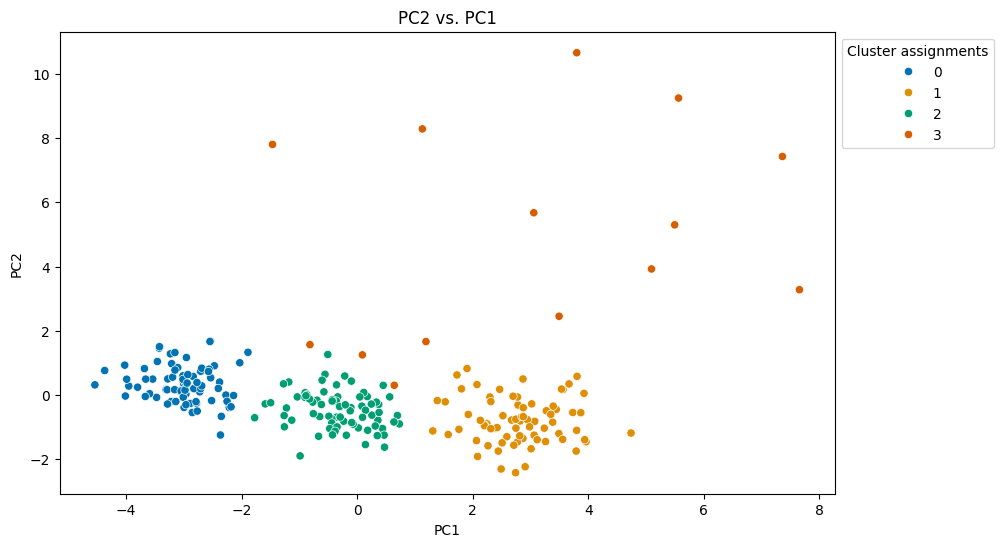


--- Part 3: PCA Visualization ---


,PC1,PC2
0,4.740672,-1.183674
1,-1.465772,7.802113
2,3.005085,-0.853267
3,-3.459311,1.043155
4,-3.074568,0.124814


In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
scaled_data = scaler.fit_transform(corrected_data)
pca = PCA(n_components = 2)

#data_pca = pca.fit_transform(scaled_data)
data_pca = pca.fit_transform(corrected_data)
data_pca = pd.DataFrame(data_pca,columns=['PC1','PC2'])
print(data_pca)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_pca, x="PC1", y="PC2", hue=my_model_labels, palette="colorblind")
plt.title("PC2 vs. PC1")
plt.legend(title="Cluster assignments", bbox_to_anchor=(1,1))
plt.show()

# --- Part 3: Visualization with PCA (5 Points) ---
print("\n--- Part 3: PCA Visualization ---")
data_pca.head()


--- Part 4: Comparison and Discussion ---


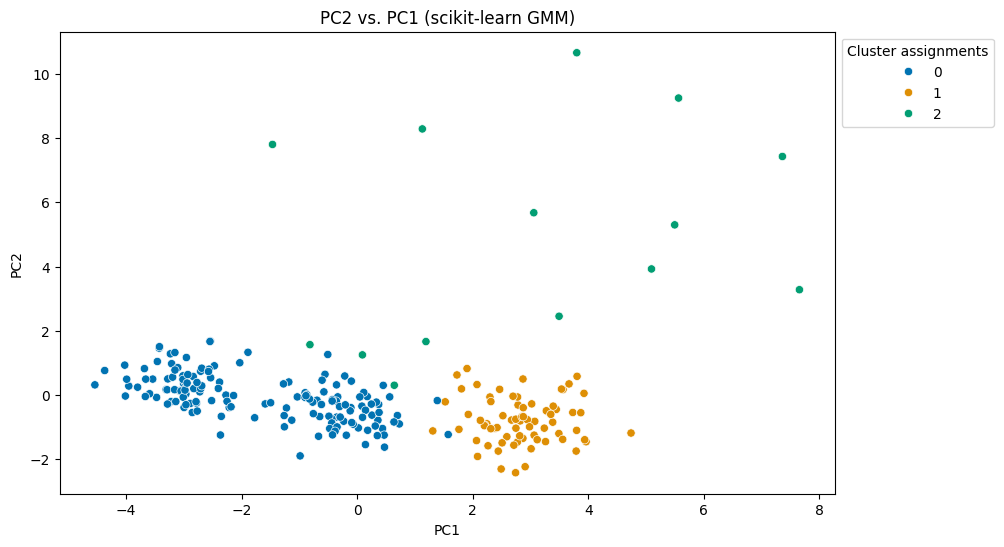

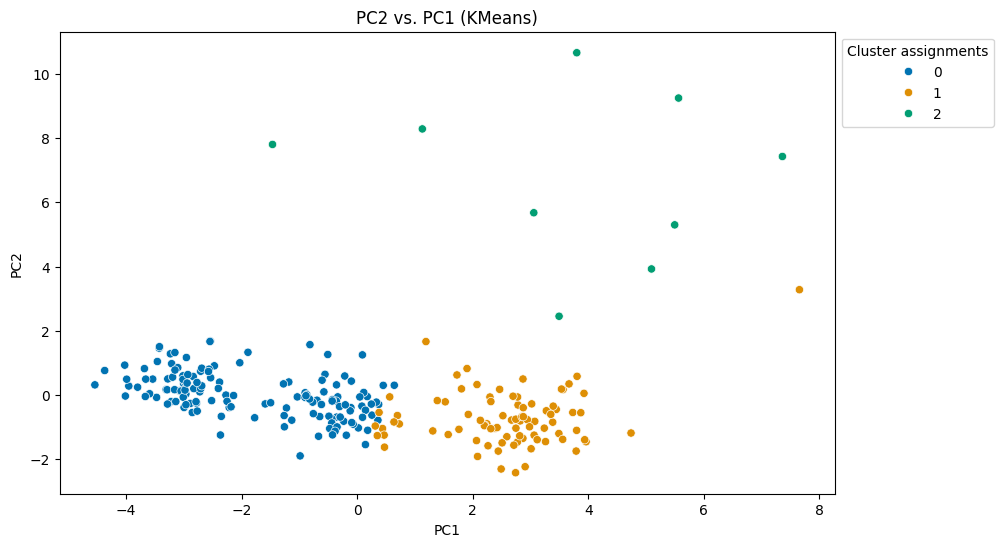

In [6]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
# --- Part 4: Comparison and Discussion (25 Points) ---
print("\n--- Part 4: Comparison and Discussion ---")

# Train scikit-learn GMM with 3 components
gmm = GaussianMixture(n_components=3, random_state=0, n_init=1)
gmm.fit(corrected_data)
labels = gmm.predict(corrected_data)

# Train KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
kmeans.fit(corrected_data)
kmeans_labels = kmeans.labels_

# Visualize sklearn GMM results
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_pca, x="PC1", y="PC2", hue=labels, palette="colorblind")
plt.title("PC2 vs. PC1 (scikit-learn GMM)")
plt.legend(title="Cluster assignments", bbox_to_anchor=(1,1))
plt.show()
# Visualize KMeans results
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_pca, x="PC1", y="PC2", hue=kmeans_labels, palette="colorblind")
plt.legend(title="Cluster assignments", bbox_to_anchor=(1,1))
plt.title("PC2 vs. PC1 (KMeans)")
plt.show()

# TODO: Write your answers to the discussion questions as comments here.
# 1. Compare the three PCA plots...
From The Robust Mixture Model PCA plot,  All the three types of rocks were correctely grouped into three clusters and the outlier data points were also put in a different cluster to be clearly identified. This different from how the KMeans and the standard GMM handle the outlier data points, in the two other plots, the outliers were grouped into a cluster identifying them as a type of rock and the three non-outlier data points were grouped into two clusters.
# 2. Discuss the advantages of explicitly modeling outliers...
Explicitly modeling outliers make it possible for us to detect outliers that would have gone unnoticed with the standard model. The outlier modelling makes it.
For manchine learning models, this means that the the performance of these models will be reliable and they would not be skewed towards the outlier data points.
For some data cleaning tasks, explicitly modelling these outliers can help in identifying the outliers so that they can removed from the data set and create a more representative data.
# 3. What are the limitations of the uniform outlier model?
There are instances where the errors or outliers are not very pronounced in the data. An instance would be the bias silica reading in our dataset, the uniform outlier model won't be able to identify errors such as these in the data set because they are too similar to the non-outlier data points in the data.
The uniform outlier model can also wrongly identify non-outlier data points as outliers in the dataset. As seen in the roboust mixture model plot above the some

<Axes: >

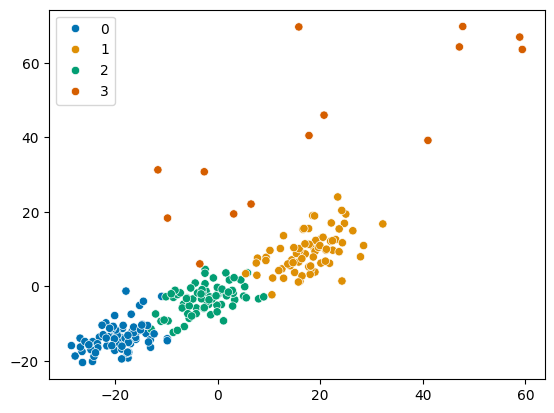

In [7]:
# --- Bonus part below
def pca_2d(X):
    mean_x = np.mean(X, axis=0)
    X = X - mean_x
    covs = np.cov(np.transpose(X))
    eigenvectors, eigenvalues = np.linalg.eig(covs)
    sorted_index = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[sorted_index]
    principal_components = eigenvectors[:2]
    return np.dot(X, np.transpose(principal_components))

pca_data = pca_2d(corrected_data)

sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1],hue=my_model_labels, palette="colorblind")